In [1]:
%load_ext autoreload

In [40]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%autoreload
import covid19_inference.covid19_inference as cov19
import utils
import plot
import model
import data_prep

# Input

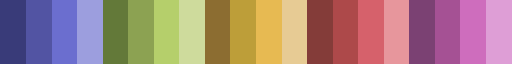

In [3]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

In [41]:
indicators = ["R"]
name = "test"

disease_data = {}

# for saving the results
tags = ""
for indicator in indicators:
    tags += indicator + "_"
tag = tags + name

# Data
## Out of home duration
o_2020, o_base, dates_2020, dates_2022 = data_prep.get_out_of_home_duration()

## Kurzarbeit
kurzarbeit = data_prep.get_kurzarbeit(dates_2020, dates_2022)

## R
if "R" in indicators:
    disease_data["R"] = data_prep.get_R(dates_2020)

## OWID
if "ICU" in indicators or "C" in indicators or "H" in indicators:
    owid = data_prep.get_owid()

### cases
if "C" in indicators:
    disease_data["C"] = data_prep.get_C(owid, dates_2020)

### ICU
if "ICU" in indicators:
    disease_data["ICU"] = data_prep.get_ICU(owid, dates_2020)

### hospitalisations
if "H" in indicators:
    disease_data["H"] = data_prep.get_H(owid, dates_2020)

## NPI
### stay at home orders
stay_at_home_2020 = data_prep.get_S(dates_2020)
### school closures
schook_closures_2020 = data_prep.get_school_closures(dates_2020)

## Weather
# to do later

# Model
inference_model = pm.Model()
model.create_model(
    inference_model,
    o_base,
    o_2020,
    stay_at_home_2020,
    schook_closures_2020,
    kurzarbeit,
    indicators,
    disease_data,
)

/data/eiftekhar/mobility_inference/data_prep.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
/data/eiftekhar/mobility_inference/data_prep.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [19]:
# convert dates to datetime
dates = pd.to_datetime(dates_2020)

# Plotting

## Cases

In [25]:
# load trace from file
tag = "C_kurzarbeit"
indicators = ["C"]
C_trace = load_trace(tag)
#C_model = load_model(indicators, {'C': case_data})

In [56]:
# load trace from file
tag = "C_test_p_linear"
indicators = ["C"]
C_trace_linear = load_trace(tag)
C_model_linear = load_model(indicators, {'C': case_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [26]:
az.summary(C_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta_o,3.451,0.983,1.854,5.278,0.041,0.031,638.0,342.0,1.01
z_C,0.120,0.022,0.085,0.162,0.001,0.001,384.0,308.0,1.00
mu_C,0.928,0.278,0.466,1.410,0.011,0.008,605.0,317.0,1.01
delta_C,0.168,0.243,0.011,0.497,0.013,0.009,572.0,307.0,1.00
z_S,0.149,0.023,0.111,0.196,0.001,0.001,525.0,342.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.134,0.155,5.876,6.410,0.008,0.006,401.0,308.0,1.00
m[33],6.050,0.154,5.795,6.322,0.008,0.005,401.0,308.0,1.00
m[34],6.018,0.153,5.749,6.276,0.008,0.005,402.0,308.0,1.00
m[35],5.984,0.151,5.738,6.249,0.008,0.005,403.0,307.0,1.00


Sampling: [delta_o]
INFO     [pymc] Sampling: [delta_o]


Directory  figures/C_kurzarbeit  already exists.


Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_C]
INFO     [pymc] Sampling: [z_C]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [delta_C, mu_C]
INFO     [pymc] Sampling: [delta_C, mu_C]
Sampling: [delta_C]
INFO     [pymc] Sampling: [delta_C]


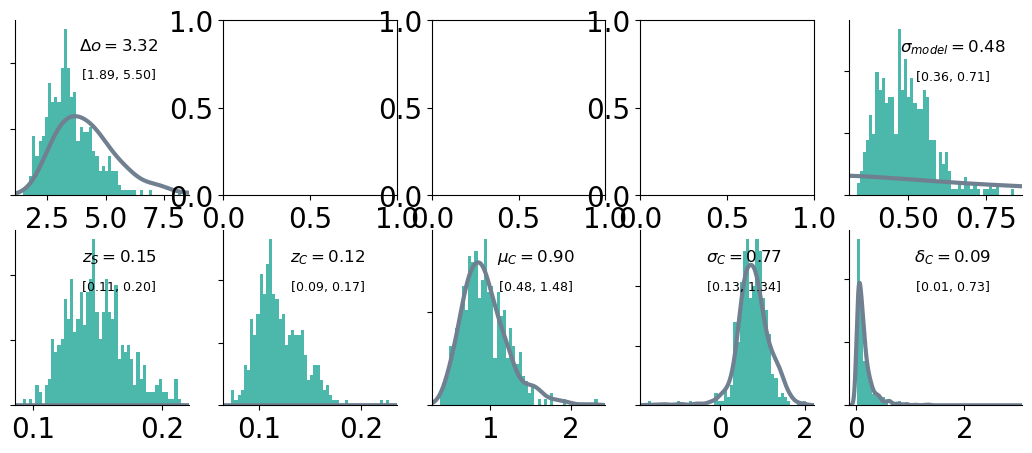

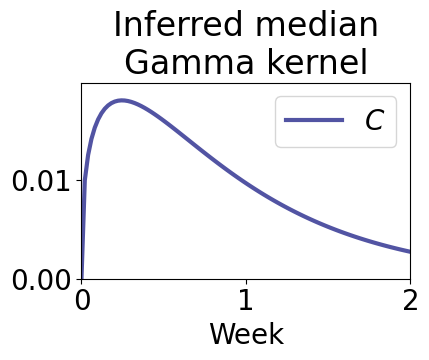

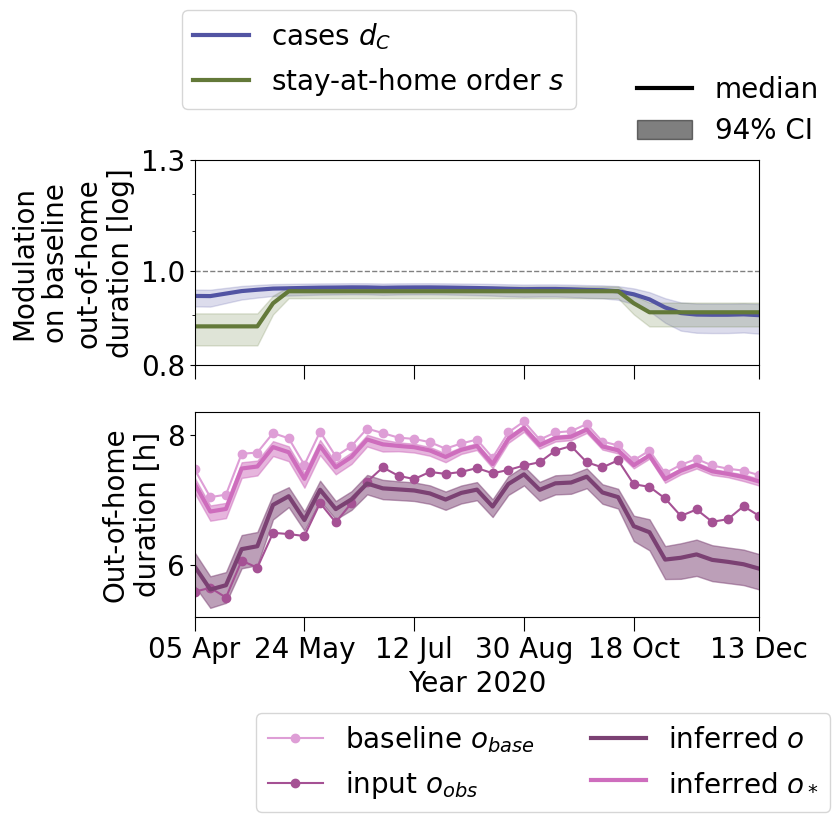

In [29]:
plot.analysis_figures(C_model, C_trace, tag, dates, indicators)

## R

In [48]:
# load trace from file
R_trace = utils.load_trace(tag)
# load model
R_model = inference_model

In [49]:
az.summary(R_trace)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta_o,3.507,0.954,1.967,5.188,0.056,0.040,304.0,308.0,1.01
z_R,0.131,0.049,0.064,0.212,0.004,0.003,167.0,137.0,1.00
mu_R,0.513,0.164,0.262,0.819,0.008,0.007,469.0,273.0,1.00
sigma_R,0.546,0.178,0.271,0.906,0.010,0.007,362.0,294.0,1.00
z_S,0.268,0.077,0.153,0.415,0.006,0.004,181.0,292.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.059,0.353,5.399,6.532,0.032,0.022,143.0,129.0,1.01
m[33],6.075,0.323,5.500,6.541,0.029,0.020,142.0,128.0,1.00
m[34],6.062,0.316,5.482,6.512,0.028,0.020,140.0,128.0,1.00
m[35],6.055,0.306,5.496,6.497,0.027,0.019,139.0,128.0,1.00


Sampling: [delta_o]
INFO     [pymc.sampling.forward] Sampling: [delta_o]


Directory  figures/R_test  already exists.


Sampling: [z_S]
INFO     [pymc.sampling.forward] Sampling: [z_S]
Sampling: [z_school]
INFO     [pymc.sampling.forward] Sampling: [z_school]
Sampling: [sigma_model]
INFO     [pymc.sampling.forward] Sampling: [sigma_model]
Sampling: [z_R]
INFO     [pymc.sampling.forward] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc.sampling.forward] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc.sampling.forward] Sampling: [sigma_R]
/data/eiftekhar/mobility_inference/covid19_inference/covid19_inference/model/utility.py:169: RuntimeWarning: divide by zero encountered in power
  distr = beta**alpha * x ** (alpha - 1) * at.exp(-beta * x)


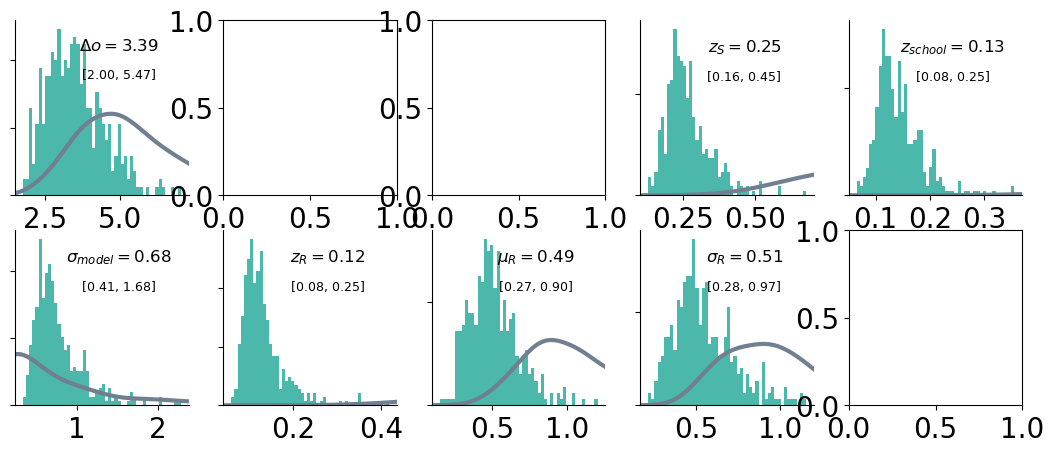

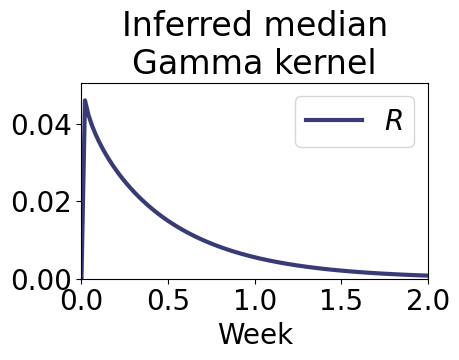

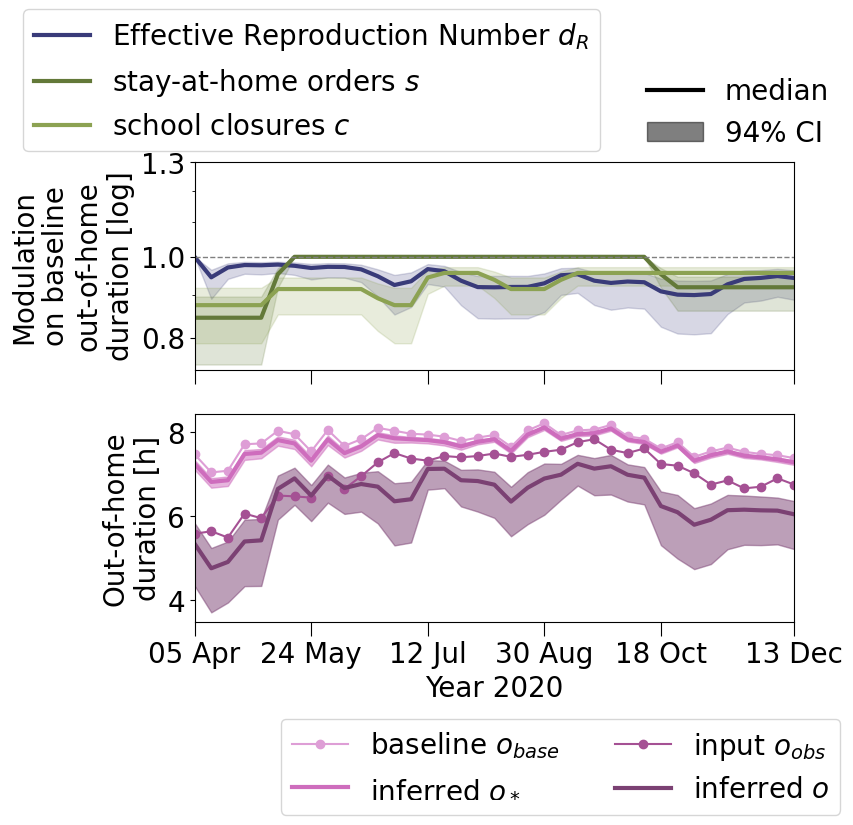

In [50]:
plot.analysis_figures(R_model, R_trace, tag, dates, indicators)

In [57]:
# load trace from file
tag = "R_test_p_linear"
indicators = ["R"]
R_trace_linear = load_trace(tag)

# load model
R_model_linear = load_model(indicators, {'R': R_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [51]:
az.summary(R_trace,  
           round_to=2,
           #var_names=['p0', 'r']
           #var_names=['del_t', 'del_p', 'tau', 'z_R', 'mu_R', 'sigma_R', 'z_S', 'sigma_model']
           )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_R,0.38,0.08,0.26,0.54,0.01,0.01,60.69,176.80,1.03
mu_R,0.90,0.31,0.43,1.47,0.02,0.01,359.68,351.26,1.00
delta_R,0.06,0.04,0.01,0.12,0.00,0.00,305.82,283.16,1.00
z_S,0.31,0.03,0.25,0.37,0.00,0.00,162.27,207.29,1.03
p0,1.19,0.07,1.08,1.32,0.01,0.01,57.98,165.24,1.04
...,...,...,...,...,...,...,...,...,...
m[32],7.03,0.08,6.88,7.19,0.00,0.00,382.73,265.20,1.00
m[33],7.00,0.08,6.85,7.14,0.00,0.00,413.84,308.00,1.00
m[34],6.99,0.08,6.87,7.15,0.00,0.00,428.30,307.15,1.00
m[35],6.97,0.08,6.85,7.13,0.00,0.00,402.66,308.28,1.00


Sampling: [p0]
INFO     [pymc] Sampling: [p0]


Directory  figures/R_test_p_linear  created.


Sampling: [p0, r]
INFO     [pymc] Sampling: [p0, r]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_R]
INFO     [pymc] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [delta_R, mu_R]
INFO     [pymc] Sampling: [delta_R, mu_R]
Sampling: [delta_R]
INFO     [pymc] Sampling: [delta_R]


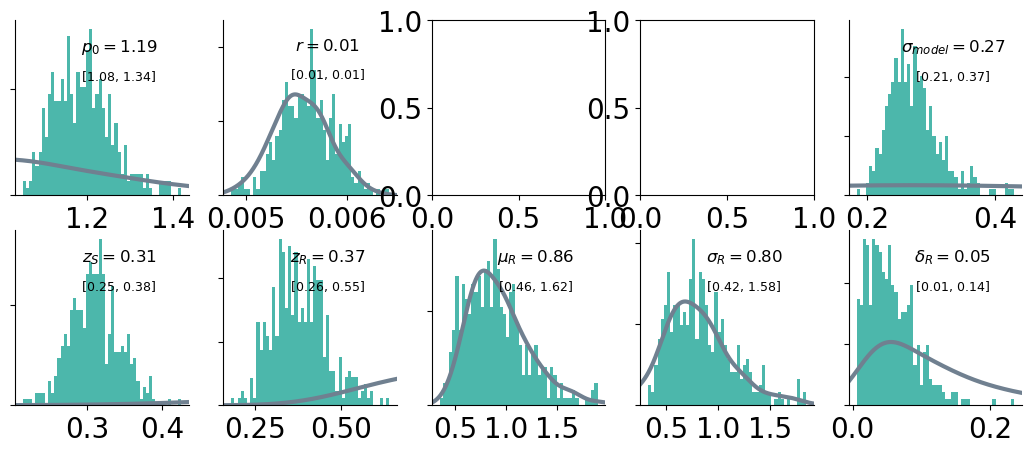

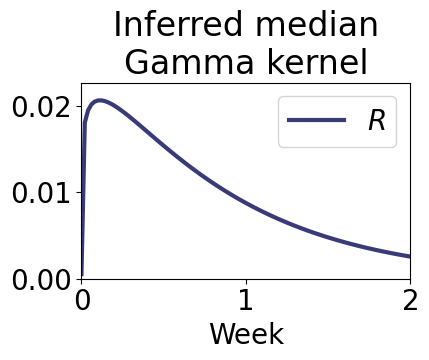

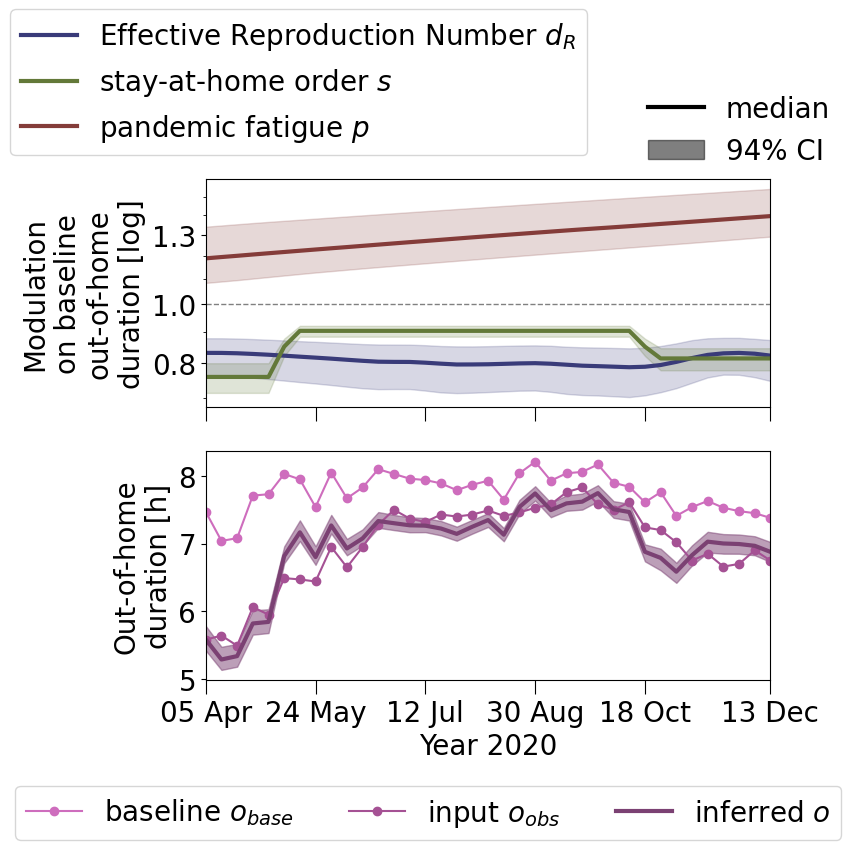

In [52]:
plot.analysis_figures(R_model, R_trace, tag, dates, indicators)

array([[<Axes: title={'center': 'z_R'}>, <Axes: title={'center': 'z_R'}>],
       [<Axes: title={'center': 'mu_R'}>,
        <Axes: title={'center': 'mu_R'}>],
       [<Axes: title={'center': 'sigma_R'}>,
        <Axes: title={'center': 'sigma_R'}>],
       [<Axes: title={'center': 'z_S'}>, <Axes: title={'center': 'z_S'}>],
       [<Axes: title={'center': 'c0'}>, <Axes: title={'center': 'c0'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'sigma_model'}>,
        <Axes: title={'center': 'sigma_model'}>],
       [<Axes: title={'center': 'd_R'}>, <Axes: title={'center': 'd_R'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'm'}>, <Axes: title={'center': 'm'}>]],
      dtype=object)

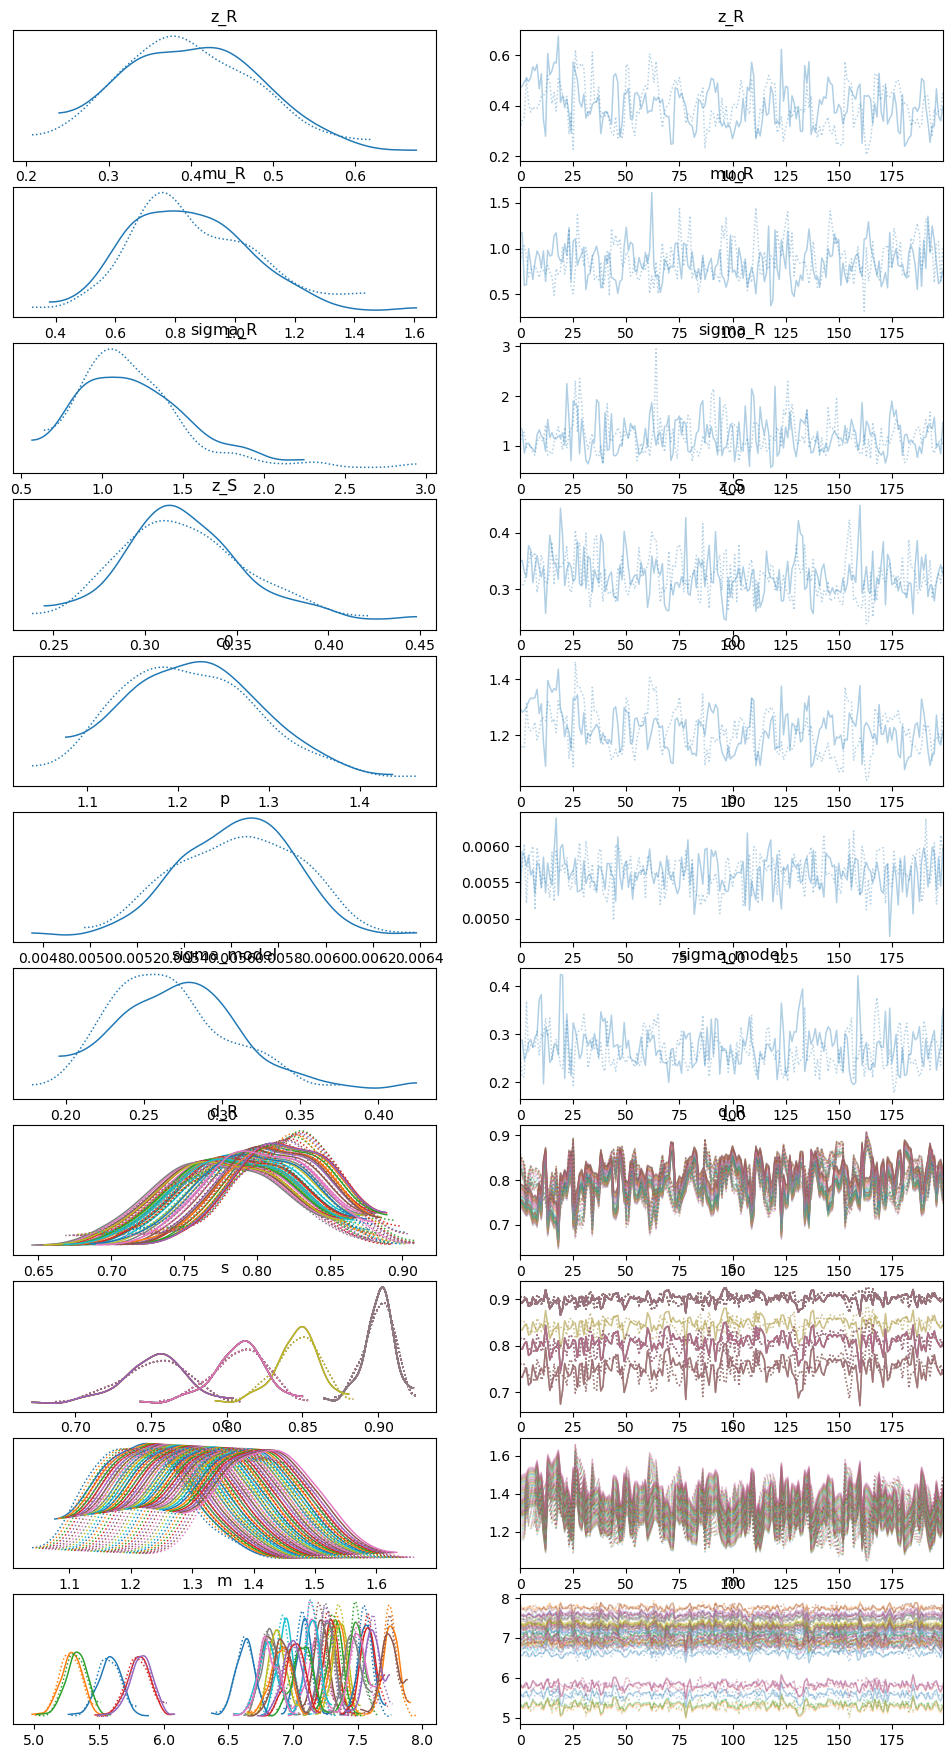

In [33]:
# plot chains
az.plot_trace(R_trace, compact=True)

## ICU

In [84]:
# load trace from file
tag = "ICU_model_full"
ICU_trace = load_trace(tag)
ICU_model = load_model(ICU_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [67]:
az.summary(ICU_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,25.051,2.060,21.383,28.895,0.111,0.079,348.0,282.0,1.01
shift,-19.886,1.888,-23.688,-16.687,0.099,0.070,361.0,282.0,1.01
z,0.139,0.020,0.103,0.178,0.001,0.001,257.0,206.0,1.01
mu,1.746,0.502,0.875,2.689,0.034,0.024,220.0,240.0,1.01
sigma,0.867,0.232,0.403,1.226,0.014,0.010,254.0,257.0,1.02
...,...,...,...,...,...,...,...,...,...
m[32],6.413,0.111,6.207,6.596,0.006,0.005,293.0,335.0,1.01
m[33],6.224,0.111,6.027,6.403,0.006,0.004,334.0,258.0,1.00
m[34],6.112,0.107,5.922,6.303,0.006,0.004,341.0,272.0,1.00
m[35],6.048,0.107,5.858,6.241,0.006,0.004,341.0,315.0,1.00


Sampling: [z]
INFO     [pymc] Sampling: [z]


Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


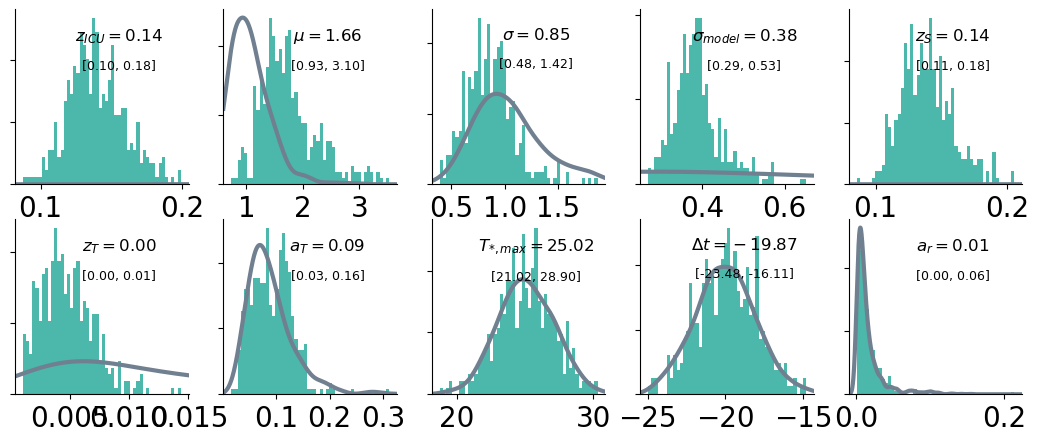

In [77]:
plot_distributions(ICU_model, ICU_trace, tag, 'z_{ICU}')

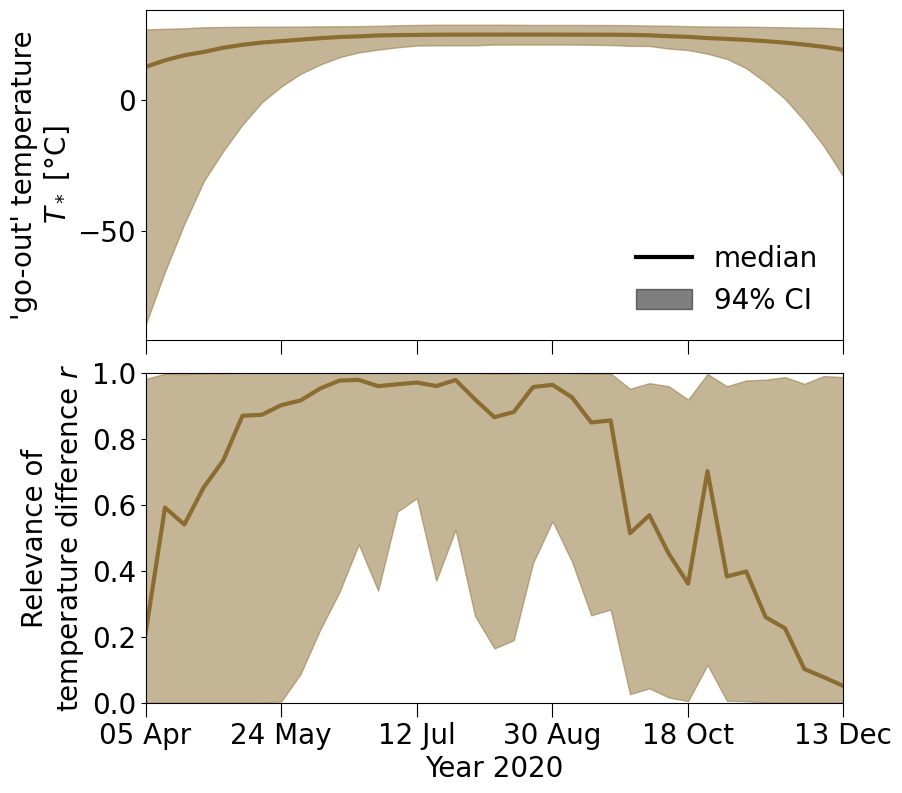

In [78]:
plot_temperature_timeseries(dates, ICU_trace, tag)

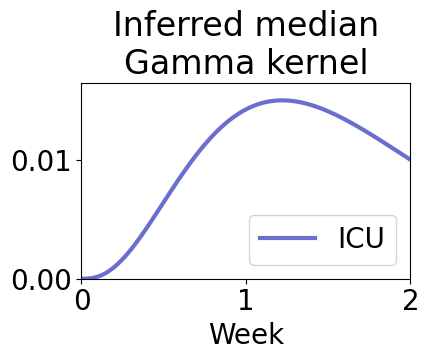

In [80]:
plot_gamma_kernel(ICU_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "ICU", "color": color_ICU})

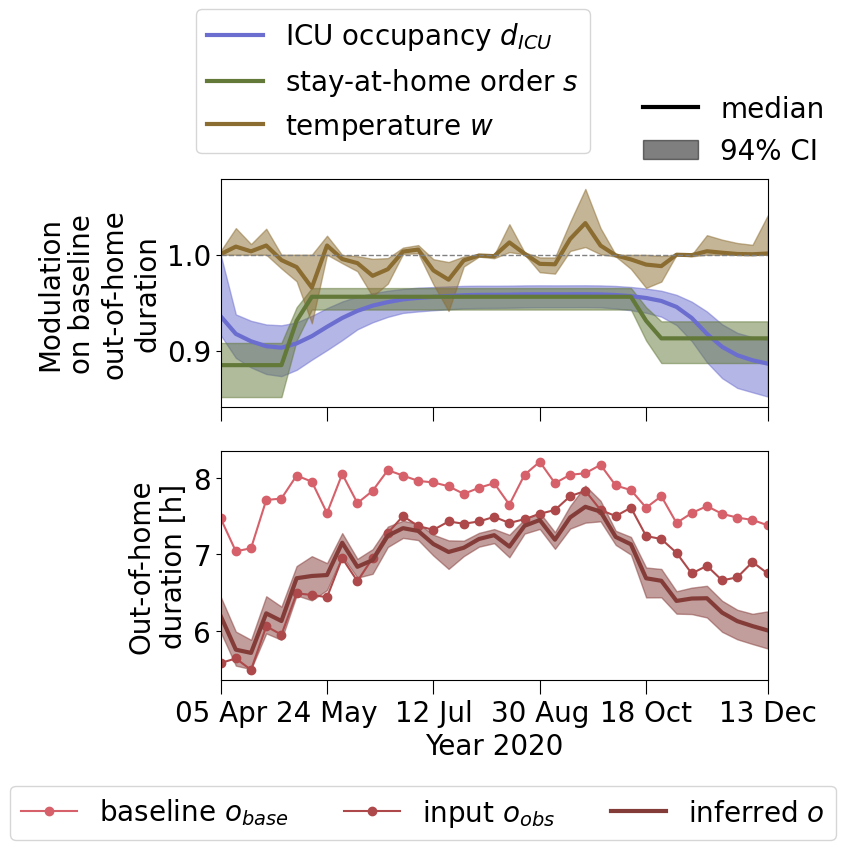

In [85]:
plot_out_of_home_duration_timeseries(
  dates,
  ICU_trace,
  tag,
  {
    "color": color_ICU,
    "del": "d",
    "del_label": "ICU occupancy $d_{ICU}$",
  },
)

## Hospitalisations

In [102]:
# load trace from file
tag = "H_model_full"
H_trace = load_trace(tag)
H_model = load_model(H_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [100]:
az.summary(H_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,25.225,2.130,21.262,29.044,0.125,0.089,282.0,240.0,1.01
shift,-19.864,2.042,-23.956,-16.314,0.104,0.075,389.0,241.0,1.00
z,0.139,0.022,0.104,0.185,0.001,0.001,350.0,365.0,1.02
mu,1.677,0.446,1.001,2.541,0.032,0.023,183.0,306.0,1.02
sigma,0.856,0.217,0.490,1.227,0.014,0.010,217.0,215.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.289,0.127,6.050,6.517,0.007,0.005,352.0,365.0,1.00
m[33],6.139,0.125,5.912,6.363,0.007,0.005,357.0,365.0,1.00
m[34],6.050,0.125,5.837,6.282,0.007,0.005,367.0,365.0,1.00
m[35],6.000,0.126,5.777,6.219,0.007,0.005,382.0,365.0,1.00


Sampling: [z]
INFO     [pymc] Sampling: [z]


Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


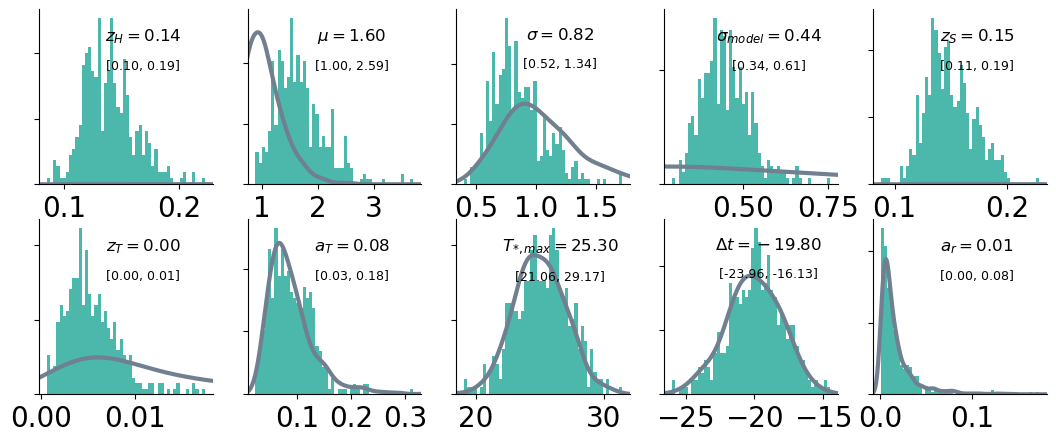

In [103]:
plot_distributions(H_model, H_trace, tag, 'z_{H}')

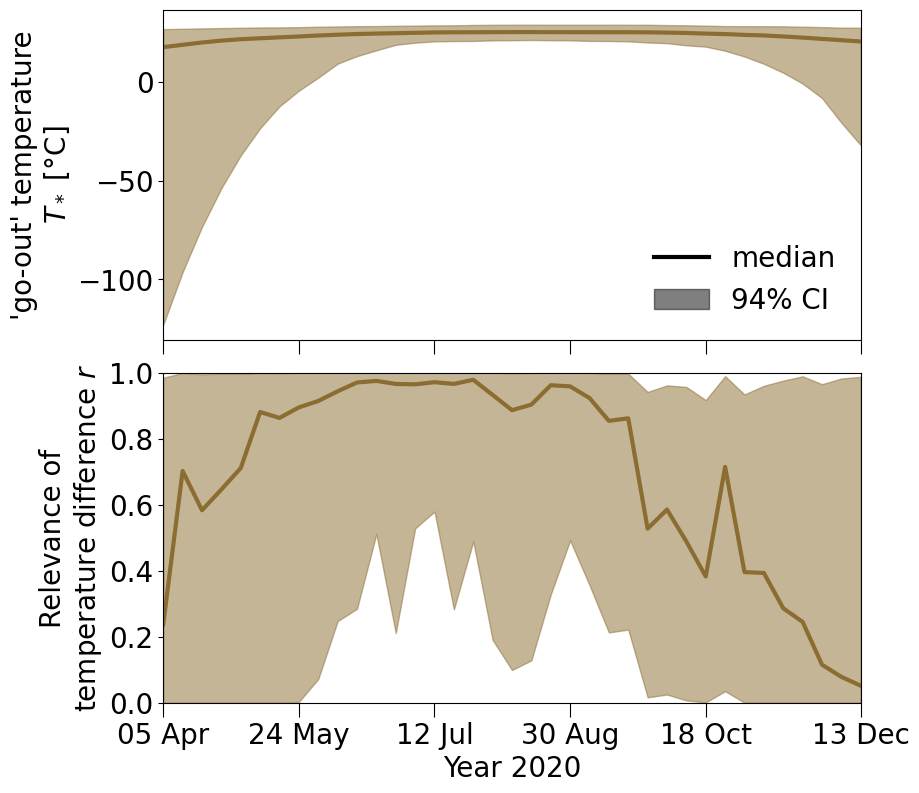

In [104]:
plot_temperature_timeseries(dates, H_trace, tag)

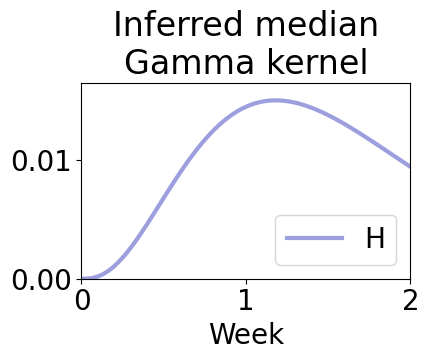

In [106]:
plot_gamma_kernel(H_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "H", "color": color_H})

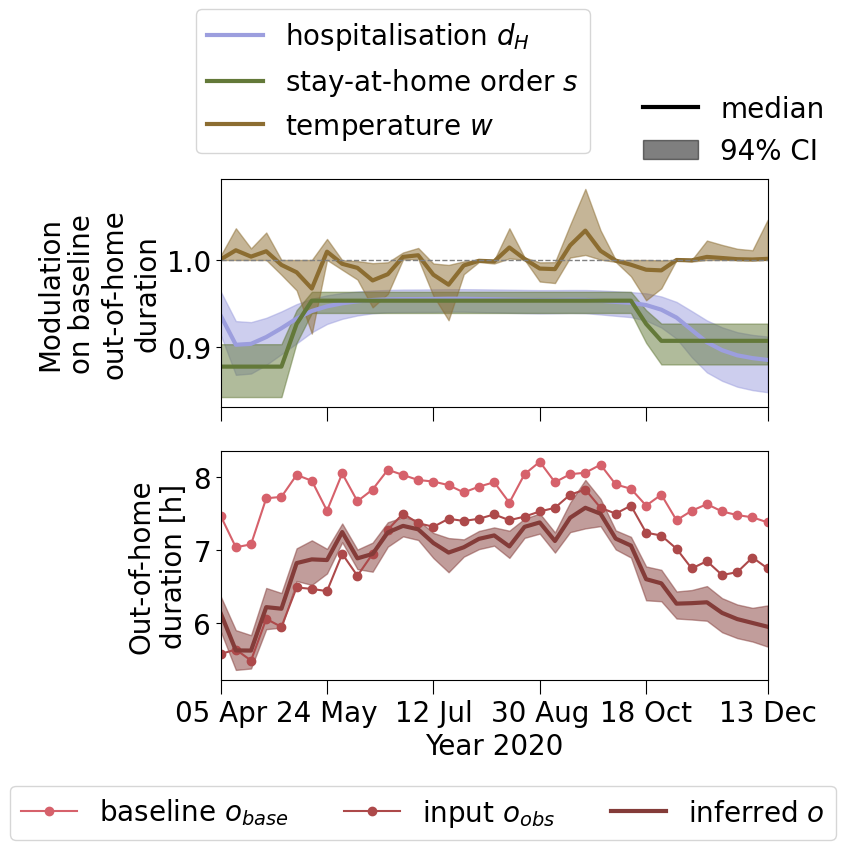

In [107]:
plot_out_of_home_duration_timeseries(
  dates,
  H_trace,
  tag,
  {
    "color": color_H,
    "del": "d",
    "del_label": "hospitalisation $d_{H}$",
  },
)

## R + cases model

In [8]:
tag = "R+cases_model_test"
RC_trace = load_trace(tag)

In [82]:
az.summary(RC_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.892,0.075,0.760,1.034,0.003,0.002,549.0,539.0,1.0
c,-0.001,0.000,-0.001,0.000,0.000,0.000,507.0,525.0,1.0
mu_R,1.569,0.242,1.135,1.990,0.012,0.009,534.0,326.0,1.0
sigma_R,1.475,0.135,1.217,1.717,0.005,0.004,721.0,641.0,1.0
mu_ICU,2.269,0.430,1.420,3.017,0.015,0.011,786.0,553.0,1.0
...,...,...,...,...,...,...,...,...,...
m[35],7.016,0.101,6.845,7.215,0.003,0.002,840.0,559.0,1.0
m[36],6.946,0.101,6.775,7.146,0.003,0.002,841.0,580.0,1.0
m[37],6.866,0.100,6.695,7.067,0.003,0.002,841.0,628.0,1.0
m[38],6.834,0.100,6.661,7.035,0.003,0.002,828.0,628.0,1.0


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

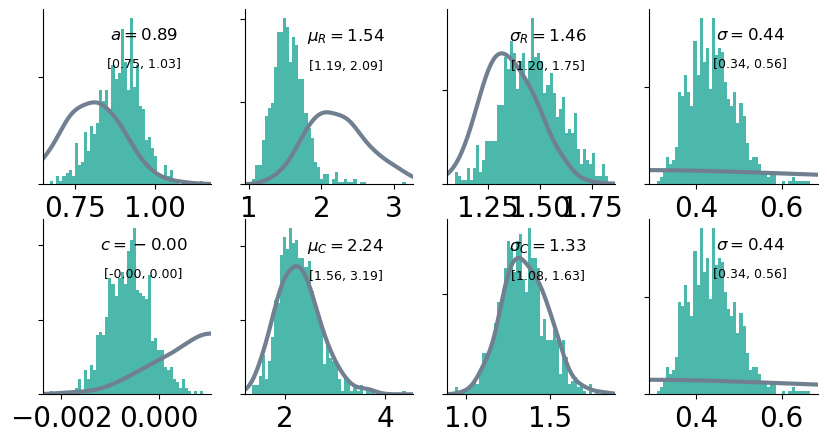

In [86]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(RC_model, RC_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(RC_model, RC_trace, 'c', dist_math='c', ax=axs[1,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_C', dist_math='\mu_{C}', ax=axs[1,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_C', dist_math='\sigma_{C}', ax=axs[1,2])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

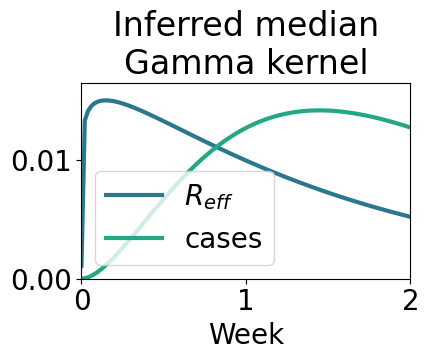

In [47]:
plot_gamma_kernel(RC_trace, 
                  tag, 
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_C", "sigma": "sigma_C", "label": "cases", "color": color_C},
                  )

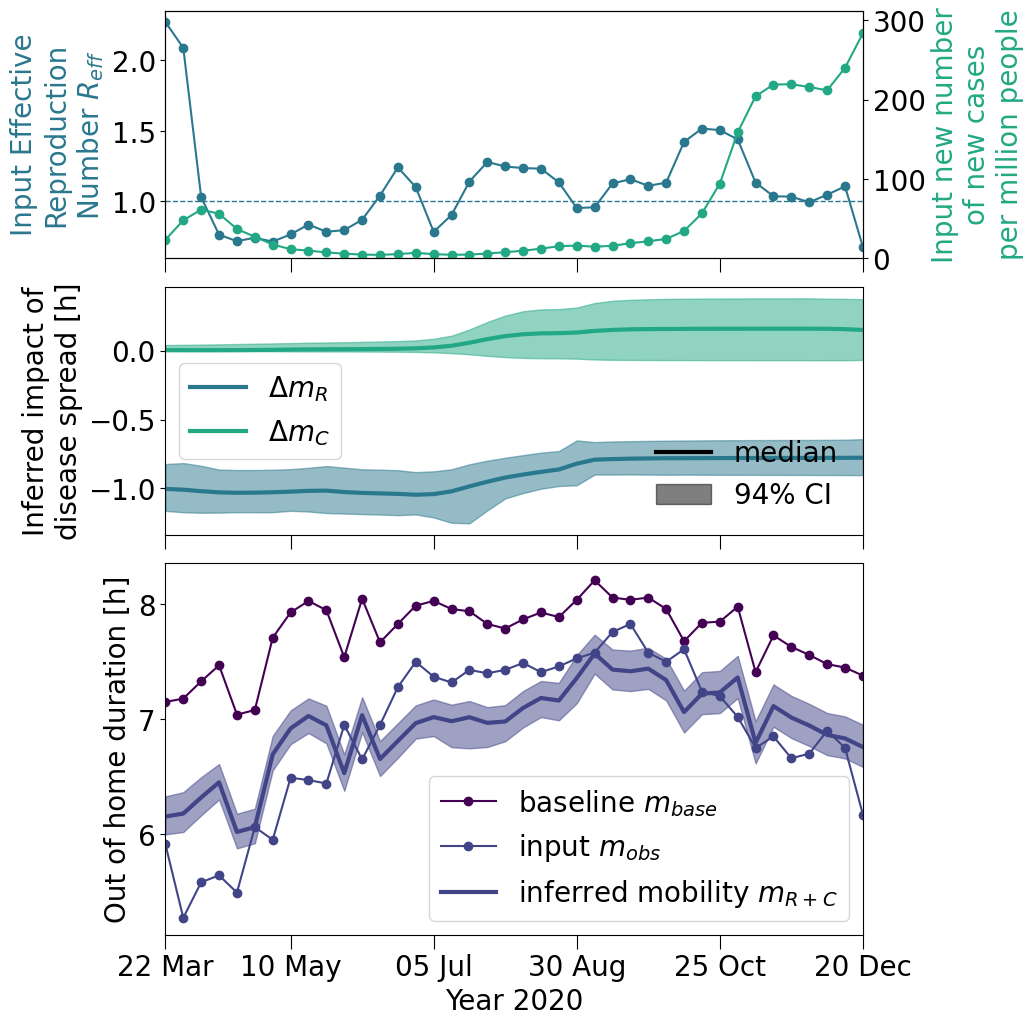

In [66]:
plot_inference_timeseries(
                          dates,
                          RC_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+C}$",
                          },
                          {
                            "constant": "cases",
                            "color": color_C,
                            "data_label": f"Input new number\nof new cases\nper million people",
                            "del": "del_m_C",
                            "del_label": "$\Delta m_C$",
                            "color_del": color_del_m_C,
                          },
                          )

## R + ICU model

In [9]:
tag = "R_ICU_test"
joint_trace = load_trace(tag)

In [54]:
az.summary(joint_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.850,0.084,0.693,1.006,0.004,0.003,499.0,409.0,1.00
b,-0.001,0.003,-0.006,0.004,0.000,0.000,549.0,447.0,1.00
mu_R,1.637,0.336,1.099,2.299,0.021,0.015,371.0,285.0,1.00
sigma_R,1.442,0.141,1.180,1.693,0.006,0.004,645.0,536.0,1.01
mu_ICU,2.251,0.458,1.493,3.217,0.015,0.011,876.0,736.0,1.00
...,...,...,...,...,...,...,...,...,...
m[35],6.945,0.111,6.741,7.172,0.003,0.002,1027.0,623.0,1.01
m[36],6.875,0.111,6.671,7.102,0.003,0.002,1027.0,623.0,1.01
m[37],6.795,0.111,6.592,7.021,0.003,0.002,1032.0,622.0,1.01
m[38],6.766,0.110,6.563,6.991,0.003,0.002,1040.0,648.0,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

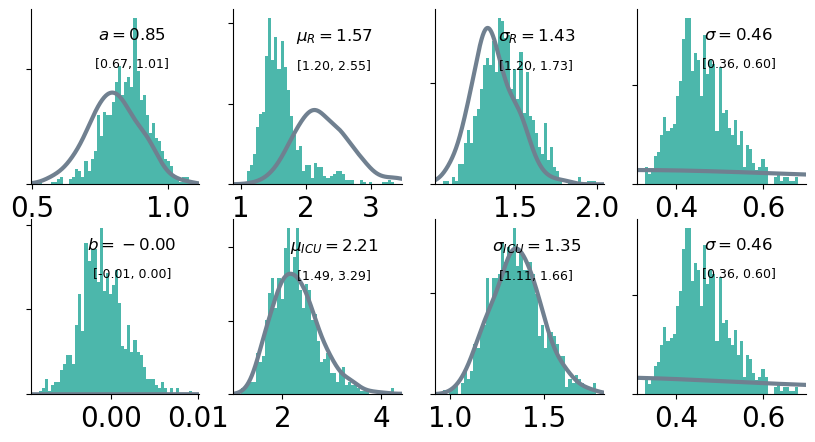

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(joint_model, joint_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(joint_model, joint_trace, 'b', dist_math='b', ax=axs[1,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[1,2])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

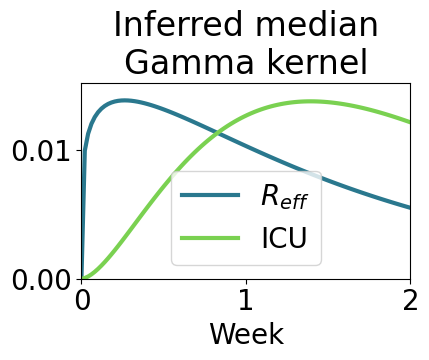

In [49]:
plot_gamma_kernel(joint_trace,
                  tag,
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_ICU", "sigma": "sigma_ICU", "label": "ICU", "color": color_ICU}
                  )

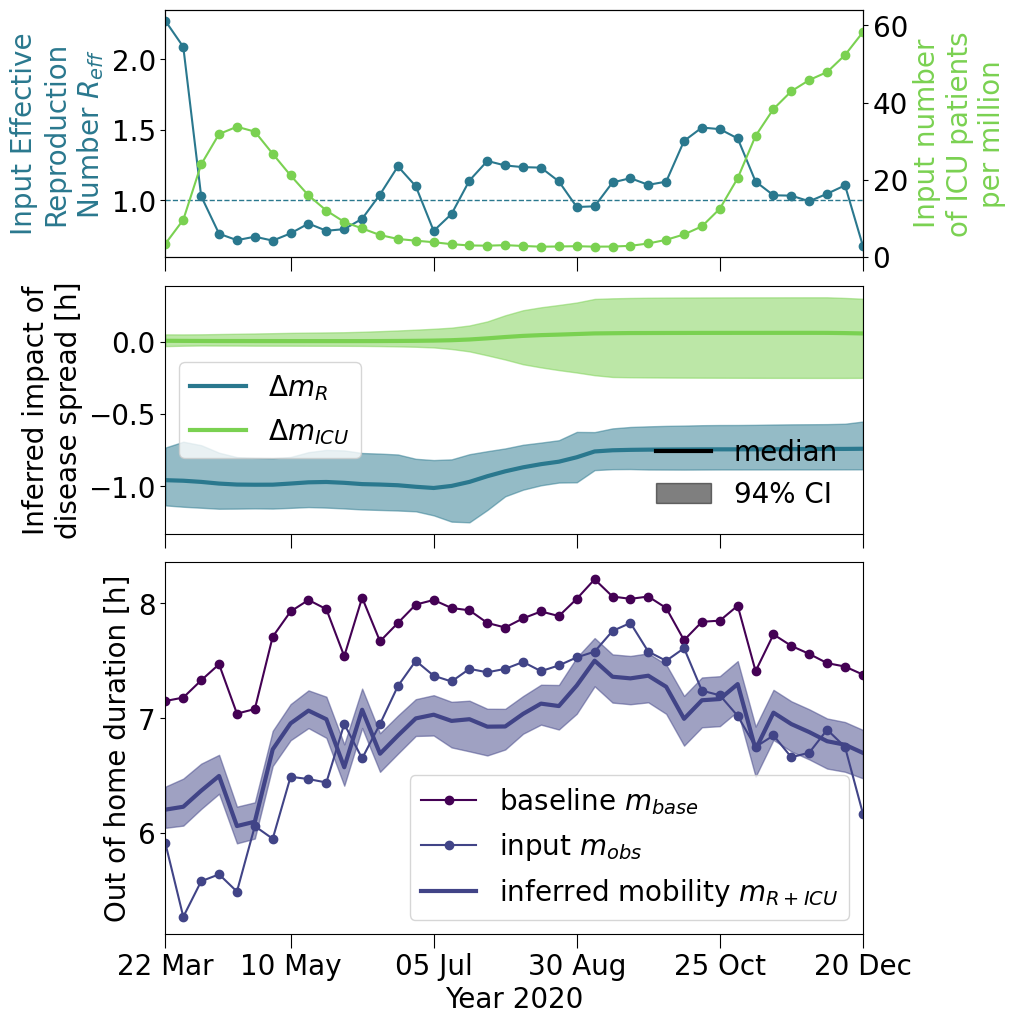

In [68]:
plot_inference_timeseries(
                          dates,
                          joint_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+ICU}$",
                          },
                          {
                            "constant": "ICU",
                            "color": color_ICU,
                            "data_label": f"Input number\nof ICU patients\nper million",
                            "del": "del_m_ICU",
                            "del_label": "$\Delta m_{ICU}$",
                            "color_del": color_del_m_ICU,
                          }
                          )

## All indicators

In [21]:
# load trace from file
tag = "R_C_ICU_H_test"
indicators = ['R', "C", 'ICU', 'H']
all_trace = load_trace(tag)
all_model = load_model(indicators, {'R': R_data, 'C': case_data, 'ICU': ICU_data, 'H': H_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [22]:
az.summary(all_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,24.970,1.949,21.628,28.878,0.100,0.071,381.0,292.0,1.01
shift,-19.877,2.049,-23.686,-15.982,0.080,0.056,662.0,252.0,1.01
z_R,0.439,0.122,0.188,0.646,0.007,0.005,385.0,158.0,1.00
mu_R,1.112,0.327,0.606,1.728,0.014,0.010,502.0,380.0,1.00
sigma_R,0.991,0.329,0.490,1.592,0.019,0.014,325.0,304.0,1.00
...,...,...,...,...,...,...,...,...,...
m[32],1.444,0.436,0.701,2.251,0.027,0.019,274.0,334.0,1.00
m[33],1.375,0.417,0.661,2.153,0.026,0.018,267.0,312.0,1.00
m[34],1.330,0.407,0.690,2.159,0.025,0.018,258.0,343.0,1.00
m[35],1.305,0.403,0.660,2.115,0.026,0.018,241.0,343.0,1.00


Directory  figures/R_C_ICU_H_test  already exists.


Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_R]
INFO     [pymc] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [z_C]
INFO     [pymc] Sampling: [z_C]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [z_ICU]
INFO     [pymc] Sampling: [z_ICU]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [z_H]
INFO     [pymc] Sampling: [z_H]
Sampling: [mu_H]
INFO     [pymc] Sampling: [mu_H]
Sampling: [sigma_H]
INFO     [pymc] Sampling: [sigma_H

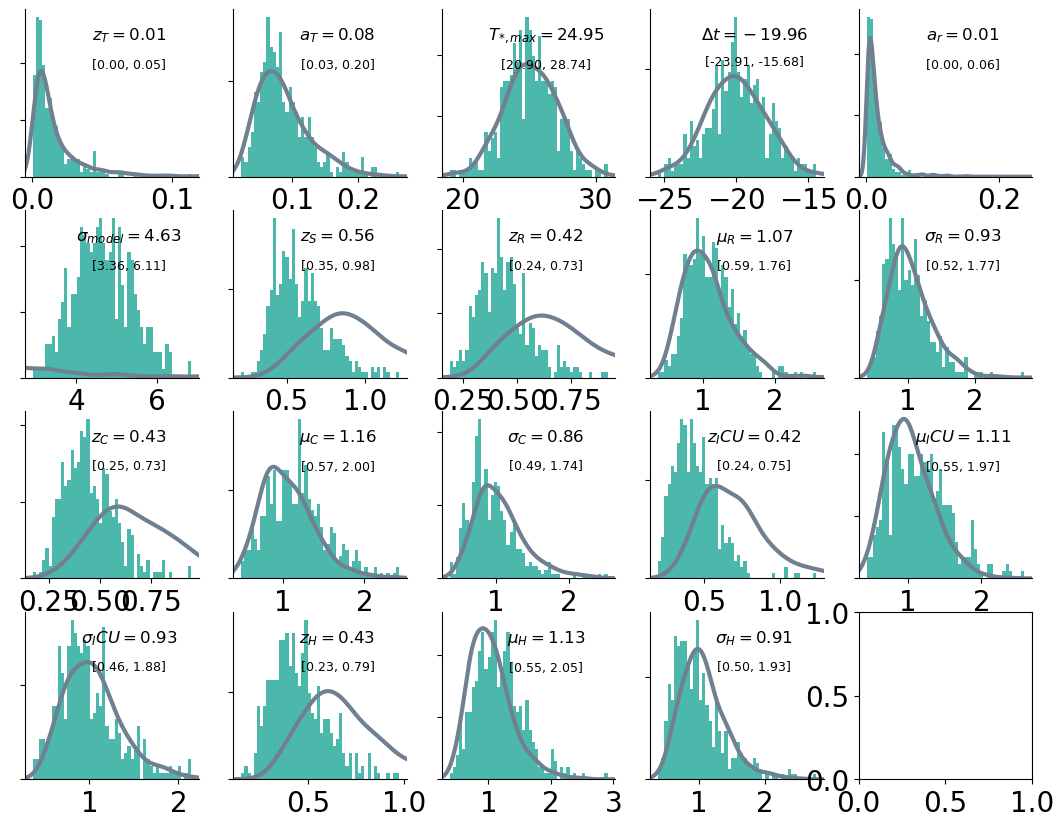

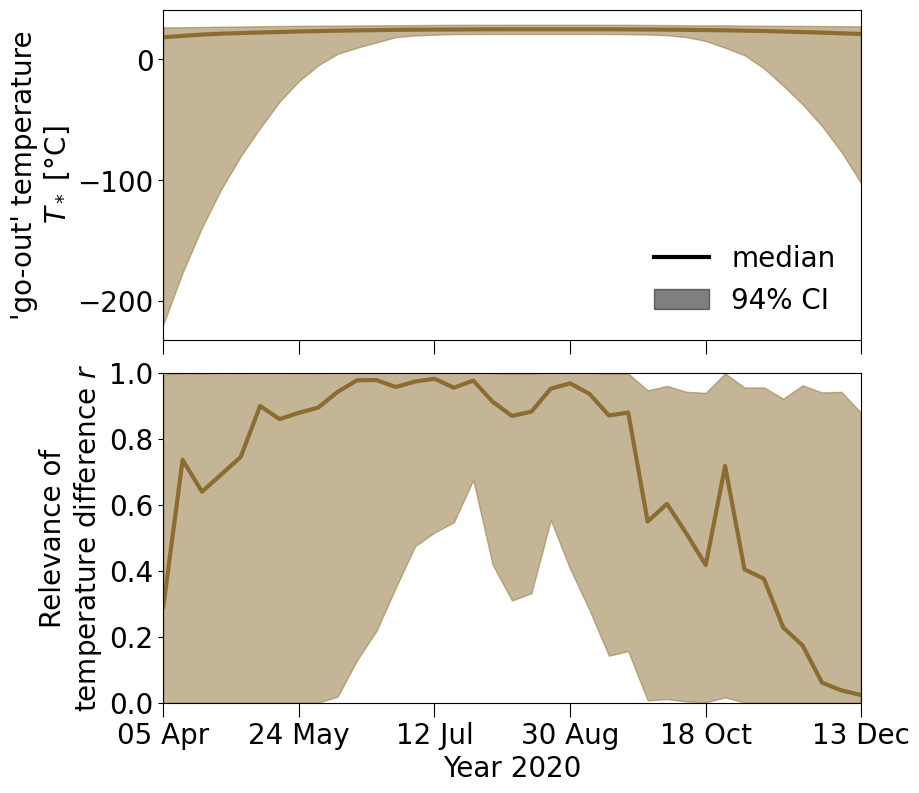

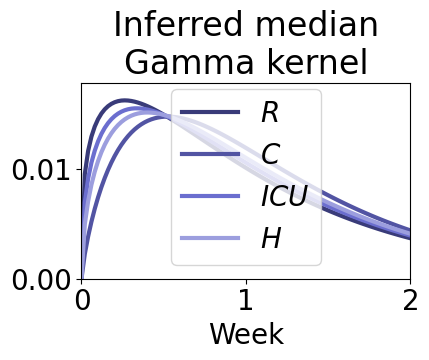

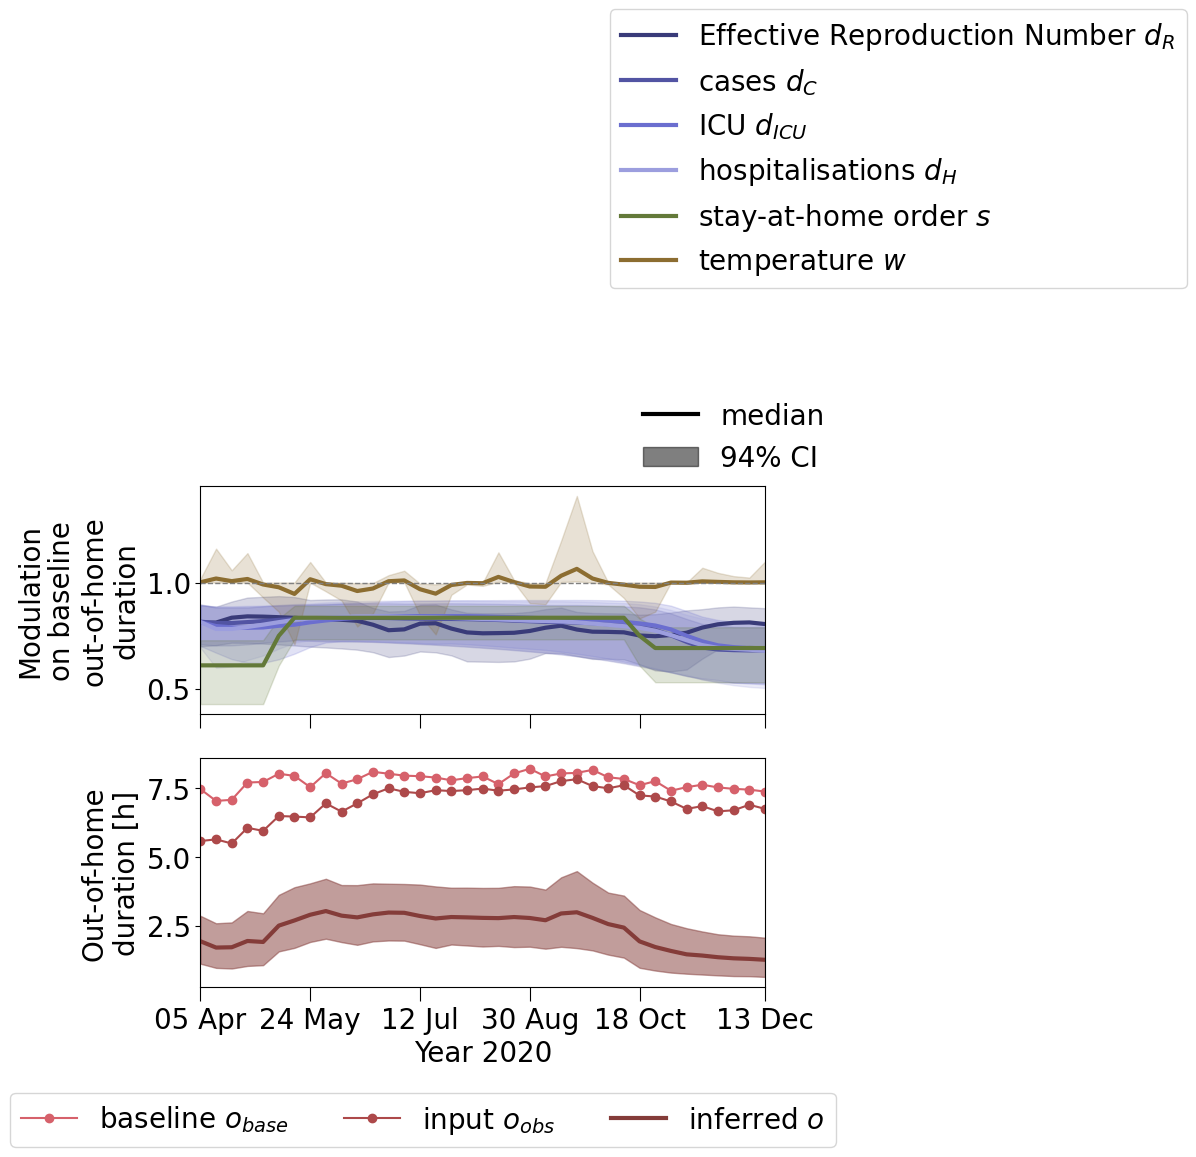

In [28]:
plot.analysis_figures(all_model, all_trace, tag, dates, indicators)

# Comparison

In [29]:
with ICU_model:
    pm.compute_log_likelihood(ICU_trace)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

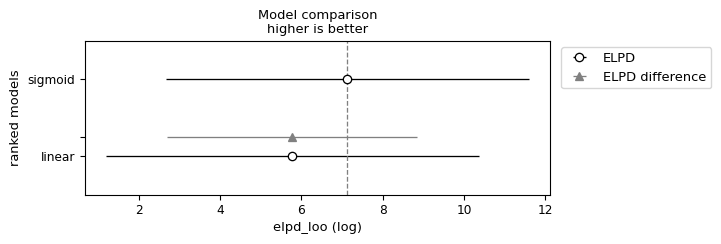

In [60]:
# for comparing pandemic fatigue models
loo = az.compare({
    "sigmoid": C_trace,
    "linear": C_trace_linear,
    }, ic="loo")
az.plot_compare(loo)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

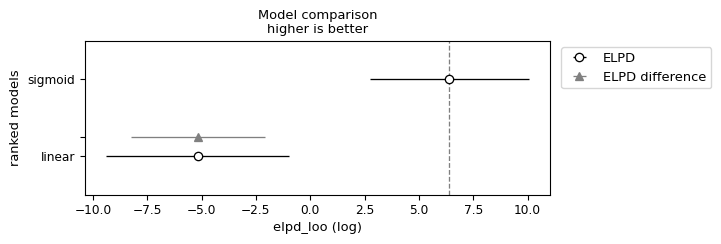

In [61]:
# for comparing pandemic fatigue models
loo = az.compare({
    "sigmoid": R_trace,
    "linear": R_trace_linear,
    }, ic="loo")
az.plot_compare(loo)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/data.nst/eiftekhar/mambaforge/

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

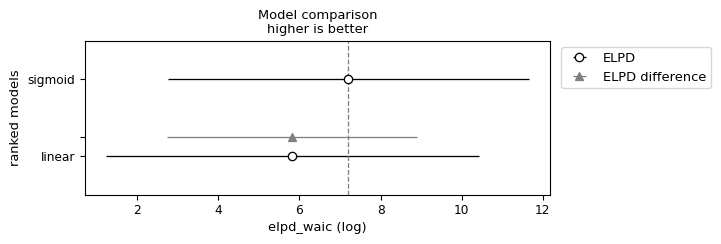

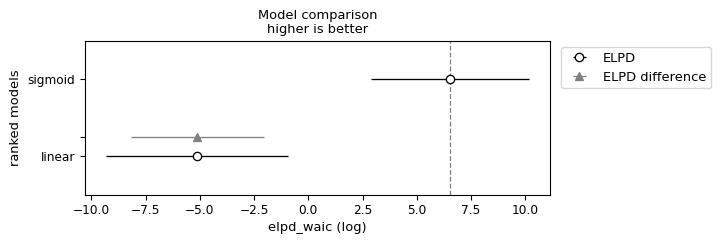

In [62]:
# for comparing pandemic fatigue models
loo = az.compare({
    "sigmoid": C_trace,
    "linear": C_trace_linear,
    }, ic="waic")
az.plot_compare(loo)

# for comparing pandemic fatigue models
loo = az.compare({
    "sigmoid": R_trace,
    "linear": R_trace_linear,
    }, ic="waic")
az.plot_compare(loo)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

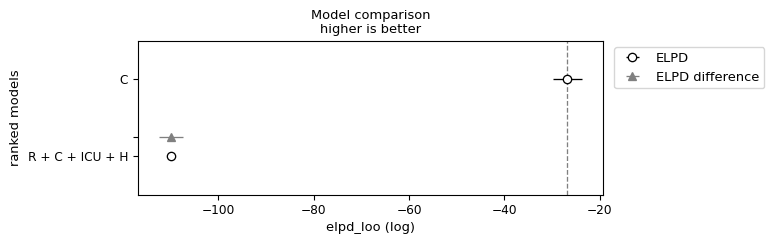

In [31]:
loo = az.compare({
    #"R + ICU": joint_trace, 
    #"R": R_trace, 
    #"ICU": ICU_trace,
    "C": C_trace,
    #"R + C": RC_trace,
    "R + C + ICU + H": all_trace
    }, ic="loo")
az.plot_compare(loo)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

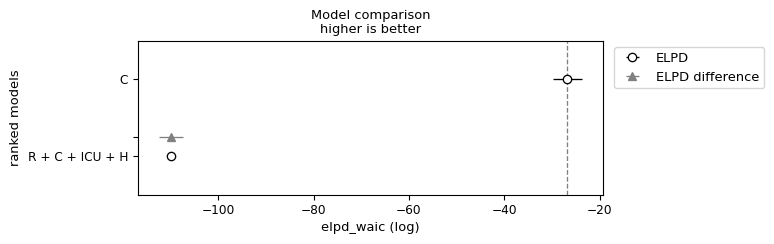

In [32]:
waic = az.compare({
    #"R + ICU": joint_trace, 
    #"R": R_trace, 
    #"ICU": ICU_trace,
    "C": C_trace,
    #"R + C": RC_trace,
    "R + C + ICU + H": all_trace
    }, ic="waic")
az.plot_compare(waic)